# Ejercicio 1 - Desarrollo

Longitud smooth1: 1000
Longitud smooth2: 1000
Train1: 995
Test1: 5
Train2: 995
Test2: 5


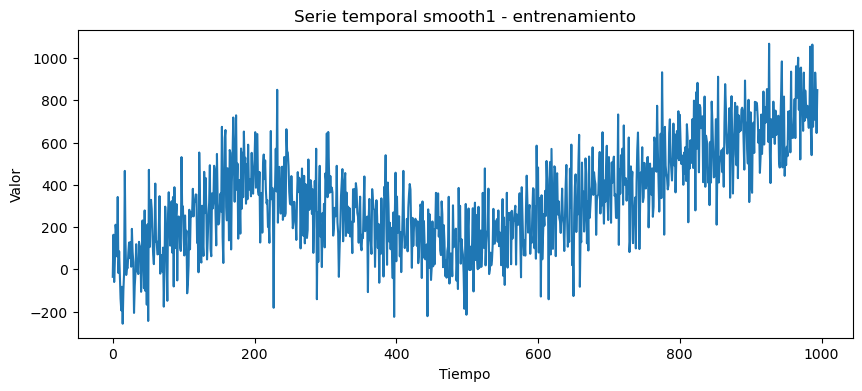

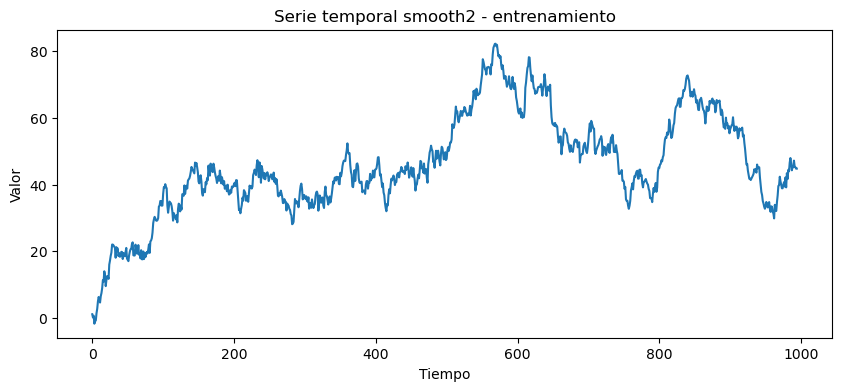

MSE smooth1: 51714.41356722929
MSE smooth2: 3.4248025547244176


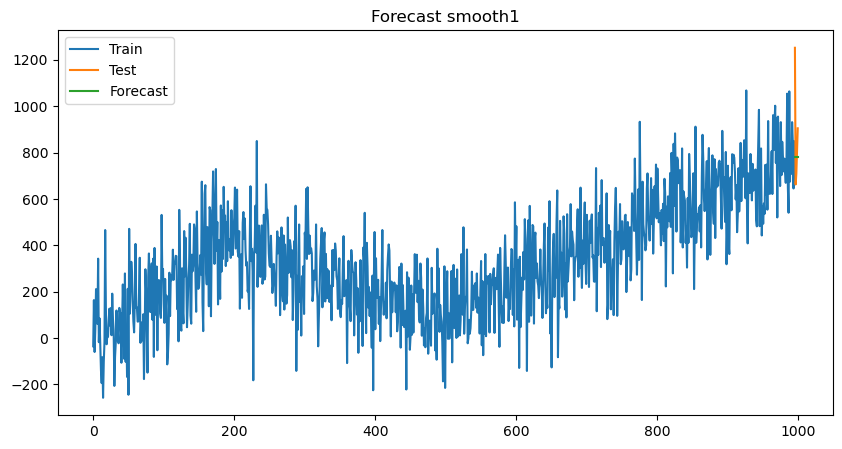

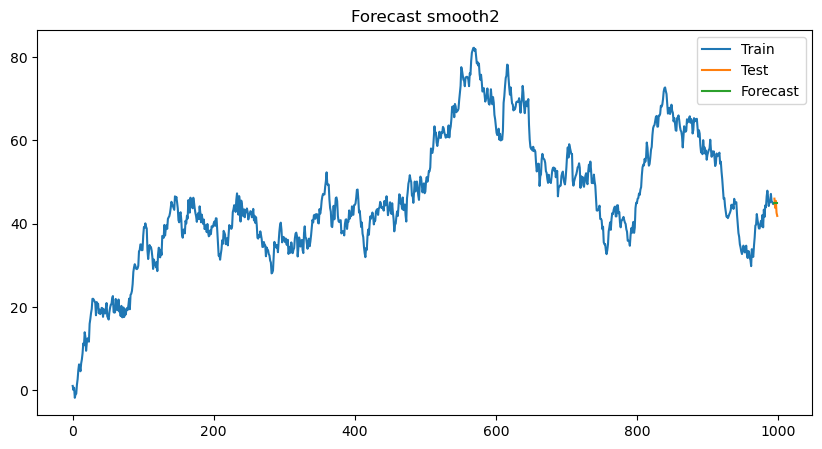

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# Leemos los archivos smooth_1.npy y smooth_2.npy
smooth1 = np.load('Appendix 1 -  smooth_1.npy')
smooth2 = np.load('Appendix 2 - smooth_2.npy')

print("Longitud smooth1:", len(smooth1))
print("Longitud smooth2:", len(smooth2))

# Creamos la variable mytime
mytime1 = np.arange(len(smooth1))
mytime2 = np.arange(len(smooth2))

# División de los datos
train1 = smooth1[:-5]
test1 = smooth1[-5:]

train2 = smooth2[:-5]
test2 = smooth2[-5:]

print("Train1:", len(train1))
print("Test1:", len(test1))

print("Train2:", len(train2))
print("Test2:", len(test2))

# Identificamos tendencia y estacionalidad
# Primero debemos visualizar los datos
plt.figure(figsize=(10,4))
plt.plot(train1)
plt.title("Serie temporal smooth1 - entrenamiento")
plt.xlabel("Tiempo")
plt.ylabel("Valor")
plt.show()

plt.figure(figsize=(10,4))
plt.plot(train2)
plt.title("Serie temporal smooth2 - entrenamiento")
plt.xlabel("Tiempo")
plt.ylabel("Valor")
plt.show()

# Creamos un modelo suavizado
window = 3

moving_avg1 = pd.Series(train1).rolling(window).mean()
moving_avg2 = pd.Series(train2).rolling(window).mean()

# Realizamo el Forecast
forecast1 = [moving_avg1.iloc[-1]] * 5
forecast2 = [moving_avg2.iloc[-1]] * 5

# Calculamos el MSE
mse1 = mean_squared_error(test1, forecast1)
mse2 = mean_squared_error(test2, forecast2)

print("MSE smooth1:", mse1)
print("MSE smooth2:", mse2)

# Graficamos Train, Test y Forecast
plt.figure(figsize=(10,5))

plt.plot(range(len(train1)), train1, label="Train")
plt.plot(range(len(train1), len(train1)+5), test1, label="Test")
plt.plot(range(len(train1), len(train1)+5), forecast1, label="Forecast")

plt.title("Forecast smooth1")
plt.legend()
plt.show()

plt.figure(figsize=(10,5))

plt.plot(range(len(train2)), train2, label="Train")
plt.plot(range(len(train2), len(train2)+5), test2, label="Test")
plt.plot(range(len(train2), len(train2)+5), forecast2, label="Forecast")

plt.title("Forecast smooth2")
plt.legend()
plt.show()

# Ejercicio 2 – Desarrollo

Longitud auto1: 100
Longitud auto2: 100


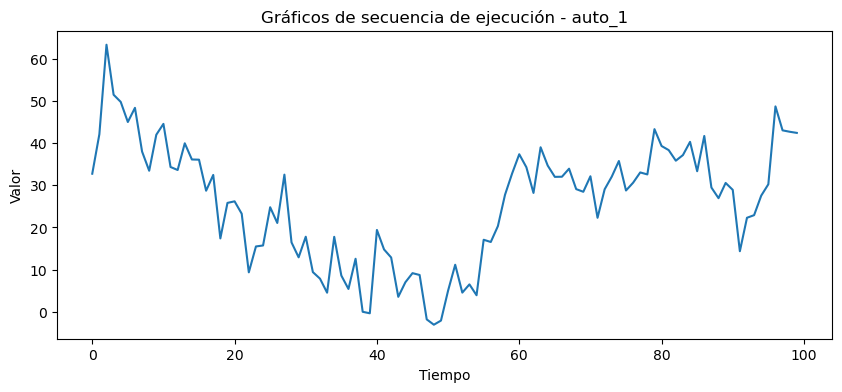

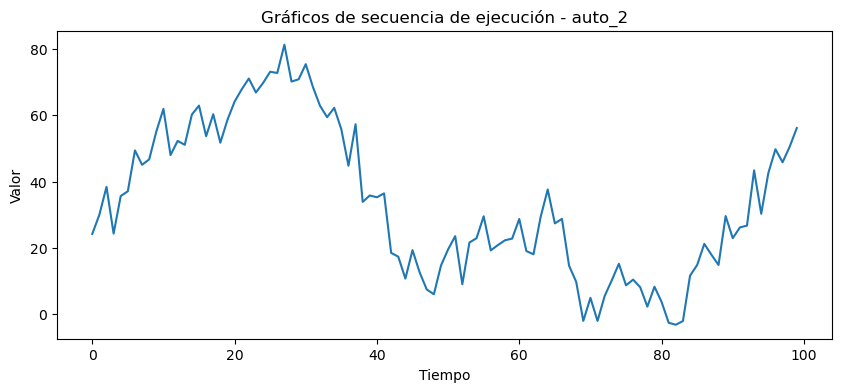

<Figure size 1000x400 with 0 Axes>

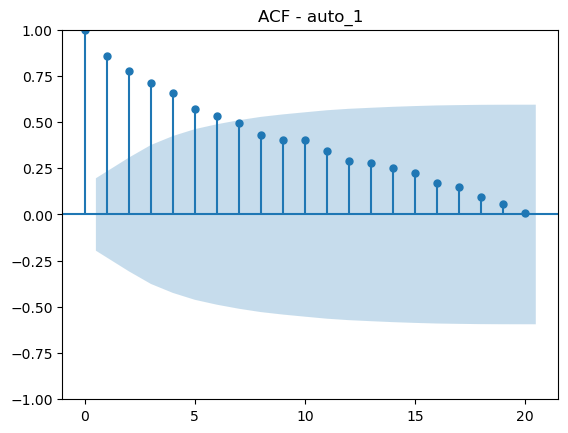

<Figure size 1000x400 with 0 Axes>

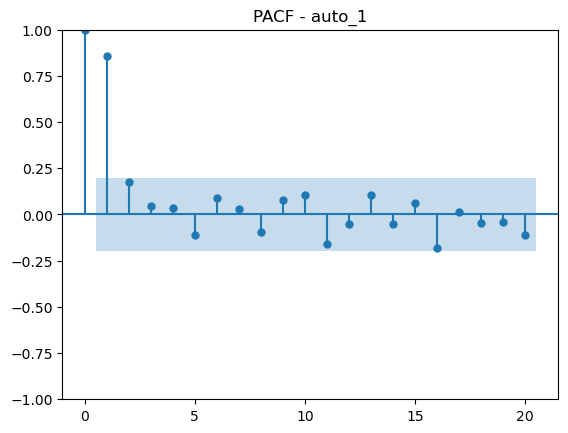

<Figure size 1000x400 with 0 Axes>

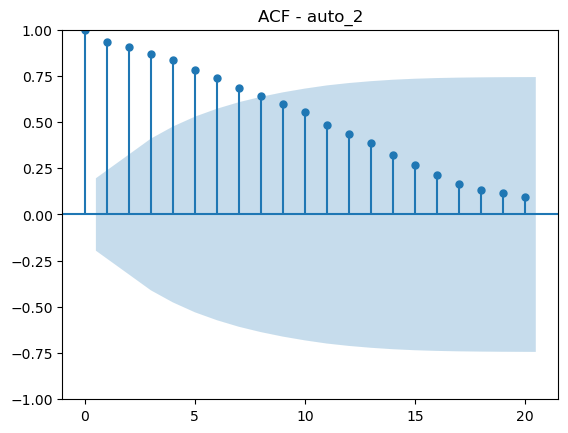

<Figure size 1000x400 with 0 Axes>

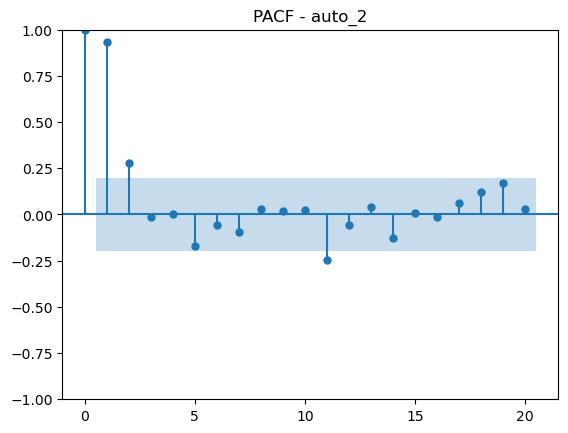

In [20]:
# Leemos los archivos auto_1.npy y auto_2.npy
auto1 = np.load('Appendix 3 - auto_1.npy')
auto2 = np.load('Appendix 4 - auto_2.npy')

print("Longitud auto1:", len(auto1))
print("Longitud auto2:", len(auto2))

# Creamos la variable de tiempo mytime
mytime1 = np.arange(len(auto1))
mytime2 = np.arange(len(auto2))

# Generamos los gráficos de secuencia de ejecución
plt.figure(figsize=(10,4))
plt.plot(mytime1, auto1)
plt.title("Gráficos de secuencia de ejecución - auto_1")
plt.xlabel("Tiempo")
plt.ylabel("Valor")
plt.show()

plt.figure(figsize=(10,4))
plt.plot(mytime2, auto2)
plt.title("Gráficos de secuencia de ejecución - auto_2")
plt.xlabel("Tiempo")
plt.ylabel("Valor")
plt.show()

# Determinar el orden p y q
# Primero importamos las funciones
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Graficamos ACF y PACF
plt.figure(figsize=(10,4))
plot_acf(auto1)
plt.title("ACF - auto_1")
plt.show()

plt.figure(figsize=(10,4))
plot_pacf(auto1)
plt.title("PACF - auto_1")
plt.show()

plt.figure(figsize=(10,4))
plot_acf(auto2)
plt.title("ACF - auto_2")
plt.show()

plt.figure(figsize=(10,4))
plot_pacf(auto2)
plt.title("PACF - auto_2")
plt.show()

# Ejercicio 3 – Desarrollo

     Month CO2 (ppm) mauna loa, 1965-1980
0  1965-01                         319.32
1  1965-02                         320.36
2  1965-03                         320.82
3  1965-04                         322.06
4  1965-05                         322.17
     Month Mean monthly temperature, 1907 ? 1972
0  1907-01                                  33.3
1  1907-02                                  46.0
2  1907-03                                  43.0
3  1907-04                                  55.0
4  1907-05                                  51.8


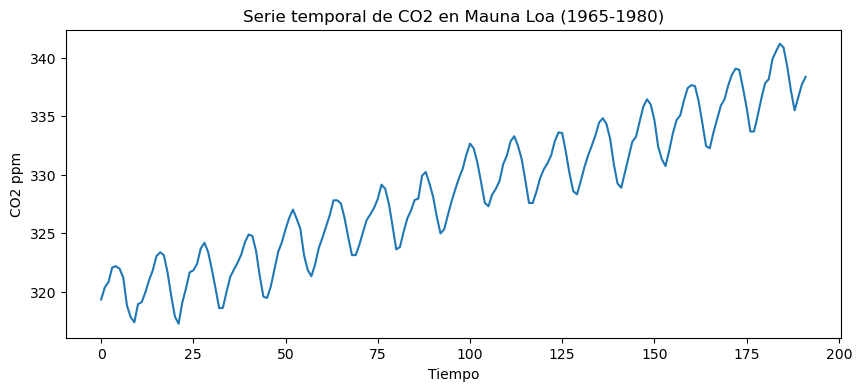

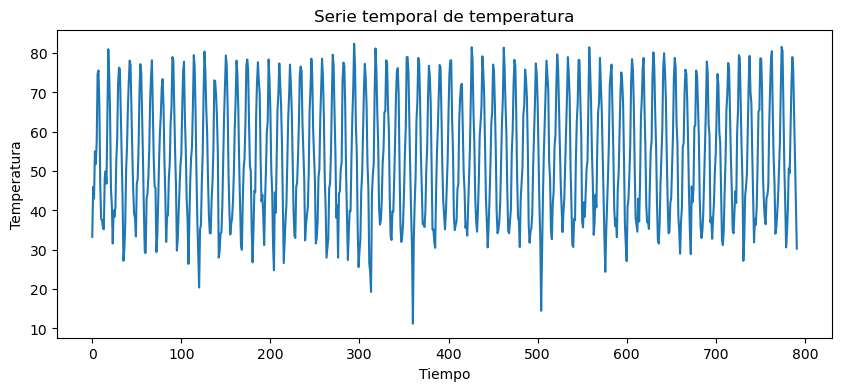

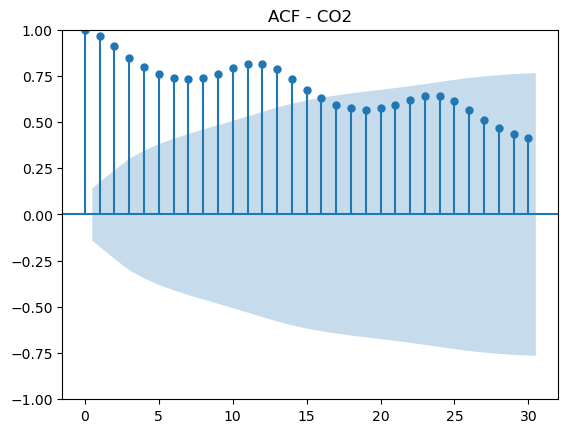

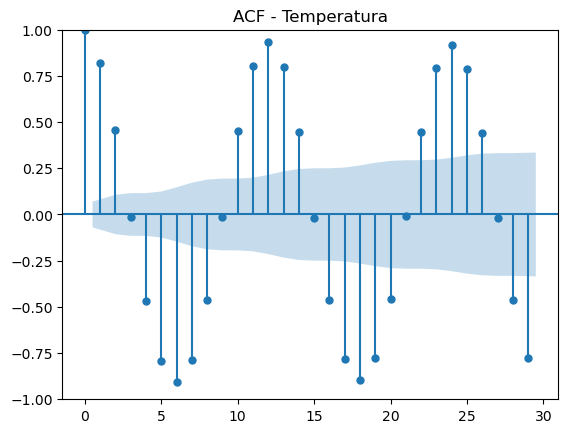

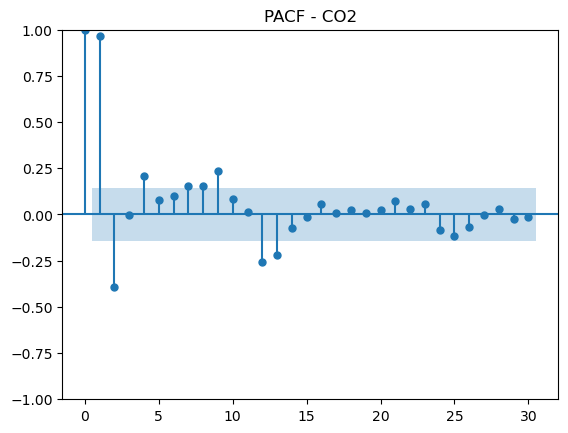

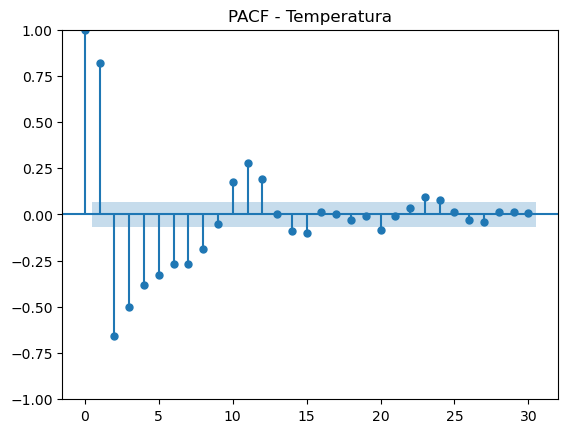

C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


                                     SARIMAX Results                                      
Dep. Variable:     CO2 (ppm) mauna loa, 1965-1980   No. Observations:                  192
Model:                             ARIMA(1, 0, 1)   Log Likelihood                -247.089
Date:                            Tue, 10 Mar 2026   AIC                            502.177
Time:                                    16:06:13   BIC                            515.207
Sample:                                         0   HQIC                           507.455
                                            - 192                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        328.4743      3.721     88.275      0.000     321.181     335.767
ar.L1          0.9786      0.017   

In [19]:
# Importamos las librerías necesarias
from statsmodels.tsa.arima.model import ARIMA

# Leemos los archivos CSV
co2 = pd.read_csv('Appendix 5 - co2-ppm-mauna-loa-19651980 1.csv')
temp = pd.read_csv('Appendix 6 - mean-monthly-temperature-1907-19.csv')

# Convertimos la columna de CO2 y Temperatura a numérica
co2_series = pd.to_numeric(co2['CO2 (ppm) mauna loa, 1965-1980'], errors='coerce')
temp_series = pd.to_numeric(temp.iloc[:,1], errors='coerce')

# Eliminar valores faltantes
co2_series = co2_series.dropna()
temp_series = temp_series.dropna()


print(co2.head())
print(temp.head())

# Graficamos las series temporales
# CO2
plt.figure(figsize=(10,4))
plt.plot(co2_series)
plt.title("Serie temporal de CO2 en Mauna Loa (1965-1980)")
plt.xlabel("Tiempo")
plt.ylabel("CO2 ppm")
plt.show()

# Temperatura
plt.figure(figsize=(10,4))
plt.plot(temp_series)
plt.title("Serie temporal de temperatura")
plt.xlabel("Tiempo")
plt.ylabel("Temperatura")
plt.show()

# Analizamos la Autocorrelation Function (ACF)
# CO2
plot_acf(co2_series, lags=30)
plt.title("ACF - CO2")
plt.show()

# Temperatura
plot_acf(temp_series)
plt.title("ACF - Temperatura")
plt.show()

# Analizamos la PACF
# CO2
plot_pacf(co2_series, lags=30)
plt.title("PACF - CO2")
plt.show()

# Temperatura
plot_pacf(temp_series, lags=30)
plt.title("PACF - Temperatura")
plt.show()

# Aplicar modelo ARMA
# CO2
from statsmodels.tsa.arima.model import ARIMA

modelo = ARIMA(co2_series, order=(1,0,1))
resultado = modelo.fit()
print(resultado.summary())

# Temperatura
modelo_temp = ARIMA(temp_series, order=(1,0,1))
resultado_temp = modelo_temp.fit()
print(resultado_temp.summary())